In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from pymongo import MongoClient
from dotenv import load_dotenv
import os

# Load environment
load_dotenv()

# Connect to MongoDB
client = MongoClient(os.getenv("MONGO_URI"))

db = client["clinical_trials_project"]
collection = db["clean_clinical_trials"]

print("Connected to MongoDB")

Connected to MongoDB


In [13]:
# Pull all documents
data = list(collection.find({}, {"_id": 0}))

df = pd.DataFrame(data)

print("Shape:", df.shape)
df.head()

Shape: (1476, 32)


,nct_id,brief_title,official_title,source_condition,overall_status,start_date,primary_completion_date,completion_date,study_type,phases,...,num_arm_groups,num_primary_outcomes,num_secondary_outcomes,num_conditions,healthy_volunteers,sex,minimum_age,is_fda_regulated_drug,is_fda_regulated_device,has_results
0,NCT07168200,A Phase III Clinical Study of Adebrelimab Comb...,"A Randomized, Controlled, Double-blind, Multic...",cancer,RECRUITING,2025-10-17,2028-04,2028-12,INTERVENTIONAL,[PHASE3],...,2,1,10,1,False,FEMALE,18 Years,False,False,False
1,NCT06582771,A Study of Sotorasib in People With Non-Small ...,A Phase 2 Study of First-line Sotorasib for Pa...,cancer,RECRUITING,2024-08-30,2026-08,2026-08,INTERVENTIONAL,[PHASE2],...,1,1,0,1,False,ALL,18 Years,True,False,False
2,NCT06790706,IMMUNORARE5: A National Platform of 5 Academic...,IMMUNORARE5: A National Platform of 5 Academic...,cancer,RECRUITING,2025-10-01,2028-11,2031-06,INTERVENTIONAL,[PHASE2],...,5,3,6,6,False,ALL,18 Years,False,False,False
3,NCT06682884,Lorlatinib as Neoadjuvant Treatment in Stage I...,"Phase II, Open-label, Single-arm, Prospective,...",cancer,NOT_YET_RECRUITING,2024-11-15,2026-04-30,2027-05-31,INTERVENTIONAL,[PHASE2],...,1,1,6,1,False,ALL,18 Years,False,False,False
4,NCT06932952,A Dose Escalation and Expansion Trial With BYO...,A Dose Escalation and Expansion Trial With the...,cancer,ACTIVE_NOT_RECRUITING,2025-05-07,2026-04,2026-12,INTERVENTIONAL,[PHASE1],...,1,2,0,1,False,ALL,18 Years,False,False,False


In [14]:
df.info()
df.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1476 entries, 0 to 1475
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   nct_id                   1476 non-null   object
 1   brief_title              1476 non-null   object
 2   official_title           1476 non-null   object
 3   source_condition         1476 non-null   object
 4   overall_status           1476 non-null   object
 5   start_date               1476 non-null   object
 6   primary_completion_date  1476 non-null   object
 7   completion_date          1476 non-null   object
 8   study_type               1476 non-null   object
 9   phases                   1476 non-null   object
 10  enrollment_count         1476 non-null   int64 
 11  enrollment_type          1476 non-null   object
 12  conditions               1476 non-null   object
 13  keywords                 1476 non-null   object
 14  lead_sponsor             1476 non-null  

,nct_id,brief_title,official_title,source_condition,overall_status,start_date,primary_completion_date,completion_date,study_type,phases,...,num_arm_groups,num_primary_outcomes,num_secondary_outcomes,num_conditions,healthy_volunteers,sex,minimum_age,is_fda_regulated_drug,is_fda_regulated_device,has_results
count,1476,1476,1476,1476,1476,1476,1476,1476,1476,1476,...,1476.000000,1476.000000,1476.000000,1476.000000,1476,1476,1454,1476,1476,1476
unique,1476,1476,1474,3,9,537,589,615,1,8,...,NaN,NaN,NaN,NaN,2,3,43,2,2,2
top,NCT07168200,A Phase III Clinical Study of Adebrelimab Comb...,"An Open Label, Randomized, Single Dose, Crosso...",heart disease,RECRUITING,2024-04-01,2026-12-31,2026-12-31,INTERVENTIONAL,[PHASE2],...,NaN,NaN,NaN,NaN,False,ALL,18 Years,False,False,False
freq,1,1,2,500,801,19,50,47,1476,372,...,NaN,NaN,NaN,NaN,1306,1343,1153,983,1461,1464
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.285908,1.813008,6.363821,2.013550,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.493794,1.866455,6.721059,1.918285,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,1.000000,0.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.000000,1.000000,2.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.000000,1.000000,5.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.000000,2.000000,9.000000,2.000000,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
# Clean fields for analysis

df_analysis = df.copy()

# Convert dates
df_analysis["start_date"] = pd.to_datetime(df_analysis["start_date"], errors="coerce")
df_analysis["completion_date"] = pd.to_datetime(df_analysis["completion_date"], errors="coerce")

# Trial duration in days
df_analysis["trial_duration_days"] = (
    df_analysis["completion_date"] - df_analysis["start_date"]
).dt.days

# Pull first phase from phase list
df_analysis["phase"] = df_analysis["phases"].apply(
    lambda x: x[0] if isinstance(x, list) and len(x) > 0 else "UNKNOWN"
)

# Clean phase labels
df_analysis["phase"] = df_analysis["phase"].replace({
    "NA": "UNKNOWN",
    "": "UNKNOWN"
})

# Optional readable phase groups
df_analysis["phase_group"] = df_analysis["phase"].replace({
    "EARLY_PHASE1": "Early",
    "PHASE1": "Early",
    "PHASE2": "Mid",
    "PHASE3": "Late",
    "PHASE4": "Post",
    "UNKNOWN": "Unknown"
})

# Make readable status groups
df_analysis["status_group"] = df_analysis["overall_status"].replace({
    "RECRUITING": "Active",
    "ACTIVE_NOT_RECRUITING": "Active",
    "NOT_YET_RECRUITING": "Active",
    "ENROLLING_BY_INVITATION": "Active",
    "COMPLETED": "Completed",
    "TERMINATED": "Stopped",
    "WITHDRAWN": "Stopped",
    "SUSPENDED": "Stopped",
    "UNKNOWN": "Unknown",
    "UNKNOWN_STATUS": "Unknown"
})

df_analysis[[
    "nct_id", "source_condition", "overall_status", "status_group",
    "phase", "phase_group", "enrollment_count", "trial_duration_days"
]].head()

,nct_id,source_condition,overall_status,status_group,phase,phase_group,enrollment_count,trial_duration_days
0,NCT07168200,cancer,RECRUITING,Active,PHASE3,Late,720,1141.0
1,NCT06582771,cancer,RECRUITING,Active,PHASE2,Mid,39,701.0
2,NCT06790706,cancer,RECRUITING,Active,PHASE2,Mid,154,2069.0
3,NCT06682884,cancer,NOT_YET_RECRUITING,Active,PHASE2,Mid,25,NaN
4,NCT06932952,cancer,ACTIVE_NOT_RECRUITING,Active,PHASE1,Early,7,573.0


In [18]:
print("Total trials:", len(df_analysis))
print("\nTrials by condition:")
print(df_analysis["source_condition"].value_counts())

print("\nTrials by status group:")
print(df_analysis["status_group"].value_counts())

print("\nTrials by phase:")
print(df_analysis["phase"].value_counts())

print("\nEnrollment summary:")
print(df_analysis["enrollment_count"].describe())

Total trials: 1476

Trials by condition:
source_condition
heart disease    500
cancer           498
diabetes         478
Name: count, dtype: int64

Trials by status group:
status_group
Active       1204
Completed     181
Stopped        56
Unknown        35
Name: count, dtype: int64

Trials by phase:
phase
PHASE2          413
PHASE1          340
PHASE4          258
PHASE3          216
UNKNOWN         199
EARLY_PHASE1     50
Name: count, dtype: int64

Enrollment summary:
count     1476.000000
mean       351.137534
std       1168.413634
min          0.000000
25%         40.000000
50%         80.500000
75%        216.000000
max      18000.000000
Name: enrollment_count, dtype: float64


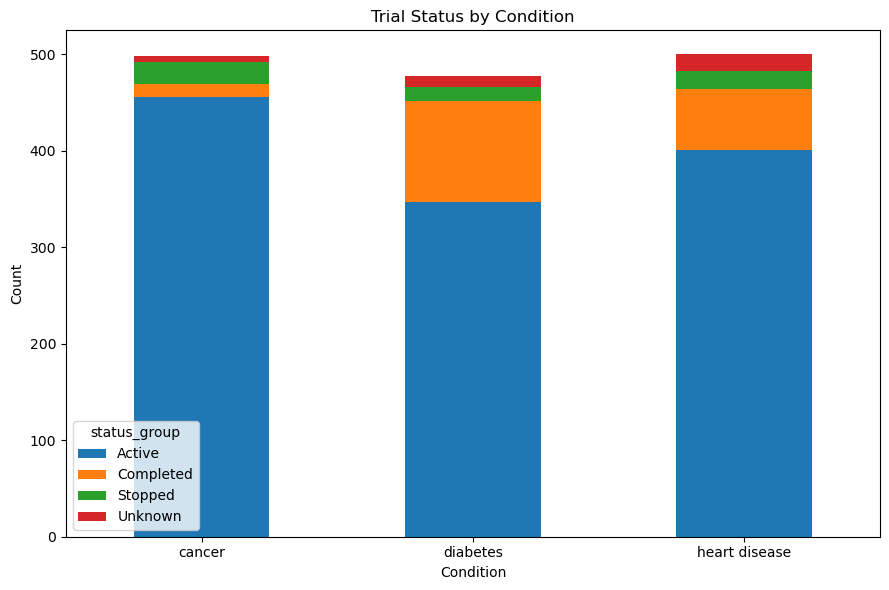

In [19]:
pd.crosstab(df_analysis["source_condition"], df_analysis["status_group"]).plot(
    kind="bar", stacked=True, figsize=(9,6)
)

plt.title("Trial Status by Condition")
plt.xlabel("Condition")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

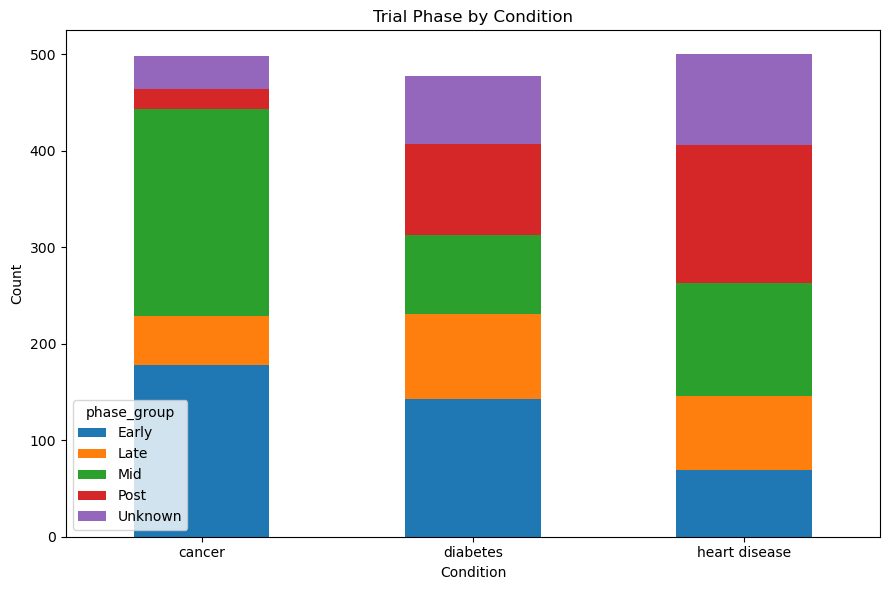

In [20]:
pd.crosstab(df_analysis["source_condition"], df_analysis["phase_group"]).plot(
    kind="bar", stacked=True, figsize=(9,6)
)

plt.title("Trial Phase by Condition")
plt.xlabel("Condition")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

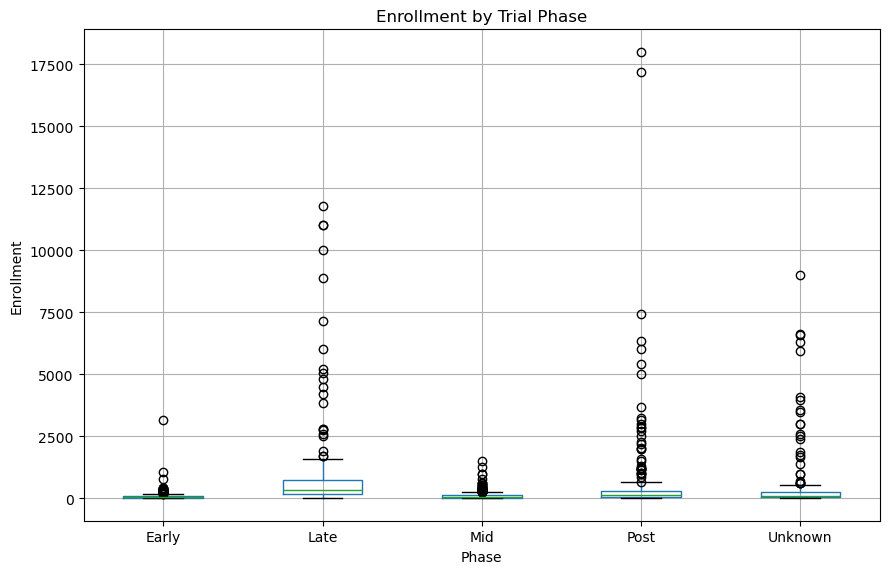

In [21]:
df_analysis.boxplot(column="enrollment_count", by="phase_group", figsize=(9,6))

plt.title("Enrollment by Trial Phase")
plt.suptitle("")
plt.xlabel("Phase")
plt.ylabel("Enrollment")
plt.tight_layout()
plt.show()

In [26]:
# Model: identify factors associated with completed trials

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Create model dataframe
df_model = df_analysis.copy()

# Target: completed vs not completed
df_model["is_completed"] = (df_model["overall_status"] == "COMPLETED").astype(int)

# Keep features that are available for both completed and non-completed trials
df_model = df_model[[
    "is_completed",
    "enrollment_count",
    "num_interventions",
    "num_conditions",
    "num_primary_outcomes",
    "num_secondary_outcomes",
    "source_condition",
    "phase_group",
    "lead_sponsor_class"
]].dropna(subset=[
    "enrollment_count",
    "num_interventions",
    "num_conditions",
    "num_primary_outcomes",
    "num_secondary_outcomes"
])

# One-hot encode categorical features
df_model_encoded = pd.get_dummies(
    df_model,
    columns=["source_condition", "phase_group", "lead_sponsor_class"],
    drop_first=True
)

X = df_model_encoded.drop(columns=["is_completed"])
y = df_model_encoded["is_completed"]

print("Model rows:", len(df_model_encoded))
print("\nTarget distribution:")
print(y.value_counts())

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Logistic regression model
model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

model.fit(X_train, y_train)

preds = model.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, preds))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, preds))
print("\nClassification Report:")
print(classification_report(y_test, preds))
from sklearn.metrics import roc_auc_score

probs = model.predict_proba(X_test)[:, 1]
print("ROC AUC:", roc_auc_score(y_test, probs))

Model rows: 1476

Target distribution:
is_completed
0    1295
1     181
Name: count, dtype: int64

Accuracy: 0.6790540540540541

Confusion Matrix:
[[173  87]
 [  8  28]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.67      0.78       260
           1       0.24      0.78      0.37        36

    accuracy                           0.68       296
   macro avg       0.60      0.72      0.58       296
weighted avg       0.87      0.68      0.73       296

ROC AUC: 0.8150641025641024


In [27]:
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coef": model.named_steps["logreg"].coef_[0]
}).sort_values("coef", ascending=False)

coef_df.head(10)

,feature,coef
5,source_condition_diabetes,1.000294
6,source_condition_heart disease,0.956286
1,num_interventions,0.186312
10,phase_group_Unknown,0.038341
12,lead_sponsor_class_INDUSTRY,0.025265
2,num_conditions,0.004839
4,num_secondary_outcomes,0.000512
3,num_primary_outcomes,-0.105467
11,lead_sponsor_class_INDIV,-0.150036
14,lead_sponsor_class_NIH,-0.189148


### Model Interpretation and Limitations

The logistic regression model achieves an ROC AUC of approximately 0.81, indicating that it is able to reasonably distinguish between completed and non-completed clinical trials based on structural features such as enrollment size, number of interventions, and study complexity. The model also shows high recall for completed trials, meaning it successfully identifies most trials that have reached completion. However, precision is relatively low, indicating that many trials predicted as completed are actually still active.

This behavior is largely driven by class imbalance and the temporal scope of the dataset. Because the data only includes trials from 2024–2025, most studies have not yet had sufficient time to reach completion. As a result, the model is not predicting long-term outcomes, but rather identifying patterns associated with trials that complete relatively early. These are typically smaller or less complex studies.

Overall, the model provides useful insight into characteristics associated with early trial completion, but its predictive power is limited by the recency of the data. A more robust model would require a longer time horizon and additional outcome data.

### Key Indicators of Trial Completion

The model identifies several structural features that are associated with whether a clinical trial reaches completion. Trials focused on diabetes and heart disease are more likely to be completed compared to cancer trials, suggesting that disease domain plays an important role in study duration and complexity. 

Study design also matters. Trials with fewer primary outcomes tend to have a higher likelihood of completion, indicating that simpler studies are easier to execute. Additionally, sponsorship type shows some influence, with trials led by industry sponsors slightly more likely to complete than those led by individual investigators or NIH-affiliated groups.

Overall, the results suggest that trial completion is closely tied to study complexity and domain, rather than any single dominant factor.

In [29]:
# Interactive model-based visualization

import plotly.express as px
import pandas as pd
from pathlib import Path

# Copy the model dataframe
model_plot_df = df_model.copy()

# Recreate encoded features to match model input
model_plot_encoded = pd.get_dummies(
    model_plot_df,
    columns=["source_condition", "phase_group", "lead_sponsor_class"],
    drop_first=True
)

X_all = model_plot_encoded.drop(columns=["is_completed"])

# Align columns with the training features
X_all = X_all.reindex(columns=X.columns, fill_value=0)

# Predicted probabilities
model_plot_df["predicted_completion_probability"] = model.predict_proba(X_all)[:, 1]

# Readable status label
model_plot_df["actual_status"] = model_plot_df["is_completed"].map({
    1: "Completed",
    0: "Not Completed"
})

# Interactive chart
fig = px.scatter(
    model_plot_df,
    x="enrollment_count",
    y="predicted_completion_probability",
    color="actual_status",
    symbol="source_condition",
    size="num_interventions",
    hover_data=[
        "source_condition",
        "phase_group",
        "lead_sponsor_class",
        "num_interventions",
        "num_conditions",
        "num_primary_outcomes",
        "num_secondary_outcomes"
    ],
    log_x=True,
    title="Model-Predicted Trial Completion Probability by Enrollment and Study Design",
    labels={
        "enrollment_count": "Enrollment Count (log scale)",
        "predicted_completion_probability": "Predicted Probability of Completion",
        "actual_status": "Actual Current Status",
        "source_condition": "Condition",
        "num_interventions": "Number of Interventions"
    }
)

fig.update_layout(
    width=1100,
    height=700,
    title_font_size=20,
    legend_title_text="Actual Status"
)

fig.show()

# Save interactive chart
docs_dir = Path("../docs")
docs_dir.mkdir(exist_ok=True)

fig.write_html("../docs/model_completion_probability_dashboard.html")

print("Saved interactive chart to docs/model_completion_probability_dashboard.html")

Saved interactive chart to docs/model_completion_probability_dashboard.html
